# Hier-COS Current-Run Trade-Off Plots

This notebook aggregates seeded Hier-COS output directories from
`/scratch/g.saggini1/outputs`. The run matrix is declared as a list of compact
requests in `RUN_REQUESTS`; each request expands into an output directory name,
a plot label, and a short code used in the summary table.

Request grammar: `(softmax, weighting, priority, *options)`.

- `softmax`: `'global'` or `'level'`;
- `weighting`: `'equal'` or `'kl_leaf'`;
- `priority`: `'no_lex'`, `'coarse_first'`, `'fine_first'`, or `'projection'`
  (projection is available only with level softmax);
- options are order-independent: a frame (`'orthonormal'` or `'identity'`), a
  transform mode (`'full'`, `'bn_linear'`, `'final_only'`), `'resnet50'`, a
  positive feature dimension for no-lex baseline or projection runs, `'advantage'`
  for projection runs, and/or a dataset-filter collection.

`projection` is the only LH-DNN-style architecture: a shared channel-wise PReLU
is always inserted before the level heads, and the projection matrix uses the
LH-DNN form `A[b] = [W_0; ...; W_(l-1)] * rho_prime(k[b])`, making the protected
subspace sample-dependent. The earlier batch-shared-`A` variant (no PReLU
derivative) has been removed.

Two ablations are toggled separately because their comparability differs:

- `INCLUDE_PRETRAINING_ABLATION` (Aircraft): pretrained/scratch x
  orthonormal/identity. The canonical Aircraft baseline is already a pretrained
  ResNet-50, so pretrained-versus-scratch is single-variable against it.
- `INCLUDE_RESNET50_ABLATION` (CIFAR-100): the same grid with
  `model.variant=haframe_resnet50` held fixed and only `model.pretrained`
  toggled. Pretrained-versus-scratch is single-variable *within this list only*.
  The CIFAR-100 `kl_leaf` no-lex baseline plotted alongside it is
  WideResNet-28-8, so those points are not a controlled comparison against it.

`conflict_only` and other transform ablations are intentionally excluded.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points, bars, and error bars are mean +/- sample standard
deviation across training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Every figure and table below reads the **independently selected** checkpoint and
the independent metric family. Top-down decoding is deliberately not offered:
its predicted path is consistent by construction, so `tice_topdown` is exactly
`0.0` in all 194 completed seed directories under `/scratch/g.saggini1/outputs`
(checked 2026-08-05) and `fpa_topdown` equals top-down fine accuracy exactly,
which leaves a top-down trade-off view with nothing to show.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

One dataset per row rather than three panels side by side: at 6.3 in a 1x3 row
leaves about 2 in per panel, which is not enough for the direct labels or for
grouped bars once a run matrix grows.

In [1]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    MECHANISM_COLORS, SHAPE_ALPHABET,
    check_encoding, discover_rows, encode_rows, model_reference_specs,
    plot_level_accuracy, plot_level_accuracy_deltas, plot_tradeoff,
    print_availability, print_reference_availability, print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'hiercos'

INCLUDE_BN_LINEAR = False
INCLUDE_LHDNN_PROJECTION = True
INCLUDE_REFERENCE_MODELS = True
INCLUDE_PRETRAINING_ABLATION = True   # Aircraft pretrained/scratch x orthonormal/identity
INCLUDE_RESNET50_ABLATION = True      # CIFAR-100 pretrained/scratch ResNet-50 x orthonormal/identity

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

In [2]:
RUN_REQUESTS = [
    # ('global', 'equal', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex', 'identity'),
    ('global', 'equal', 'coarse_first'),
    ('global', 'equal', 'coarse_first', 'identity'),
    # ('global', 'equal', 'fine_first'),
    ('global', 'kl_leaf', 'coarse_first'),
    # ('level', 'kl_leaf', 'no_lex'),
    # ('level', 'kl_leaf', 'no_lex', 'identity'),
    # ('level', 'kl_leaf', 'no_lex', 'identity', 512),
    # ('level', 'equal', 'coarse_first'),
    # ('level', 'equal', 'coarse_first', 'identity'),
    # ('level', 'kl_leaf', 'coarse_first'),
]

if INCLUDE_BN_LINEAR:
    RUN_REQUESTS.extend([
        ('global', 'equal', 'coarse_first', 'orthonormal', 'bn_linear'),
        ('level', 'equal', 'coarse_first', 'orthonormal', 'bn_linear'),
        ('level', 'equal', 'coarse_first', 'identity', 'bn_linear'),
    ])

if INCLUDE_LHDNN_PROJECTION:
    RUN_REQUESTS.extend([
        ('level', 'kl_leaf', 'projection', 'identity'),
        ('level', 'equal', 'projection', 'identity'),
        ('level', 'kl_leaf', 'projection', 'identity', 512),
        ('level', 'equal', 'projection', 'identity', 512),
        # ('level', 'kl_leaf', 'projection', 'identity', 512, 'advantage', {'cub200'}),
    ])

# (pretraining, frame) with pretraining in {'pretrained', 'scratch'}.
# Aircraft-only; see scripts/hiercos/run_hiercos_aircraft_pretraining_ablation.sh.
PRETRAINING_ABLATION_REQUESTS = [
    ('pretrained', 'orthonormal'),
    ('pretrained', 'identity'),
    ('scratch', 'orthonormal'),
    ('scratch', 'identity'),
]

# Same shape, CIFAR-100-only; see
# scripts/hiercos/run_hiercos_cifar100_resnet50_pretrained.sh.
RESNET50_ABLATION_REQUESTS = [
    ('pretrained', 'orthonormal'),
    # ('pretrained', 'identity'),
    ('scratch', 'orthonormal'),
    ('scratch', 'identity'),
]

In [3]:
SOFTMAX_SPECS = {
    'global': {'loss': 'global_softmax_ce_reg', 'label': 'Global', 'code': 'G'},
    'level': {'loss': 'level_softmax_ce_reg', 'label': 'Level', 'code': 'L'},
}

LOSS_COLORS = {'Global': '#0072B2', 'Level': '#D55E00'}
PRIORITY_LABELS = {
    'no_lex': 'No lex', 'coarse_first': 'Coarse-first lex',
    'fine_first': 'Fine-first lex', 'projection': 'LH-DNN projection',
}
PRIORITY_CODES = {'no_lex': 'N', 'coarse_first': 'C', 'fine_first': 'F', 'projection': 'P'}

# Colour encodes the mechanism, using the same vocabulary as every other
# notebook.
MECHANISM_BY_PRIORITY = {
    'no_lex': 'baseline', 'coarse_first': 'lex',
    'fine_first': 'lex', 'projection': 'projection',
}
WEIGHT_CODES = {'equal': 'E', 'kl_leaf': 'K'}
WEIGHT_LABELS = {'equal': 'Equal', 'kl_leaf': 'kl_leaf'}
TRANSFORM_CODES = {'full': '', 'bn_linear': '/BN-L', 'final_only': '/FO'}
TRANSFORM_LABELS = {'full': 'Full', 'bn_linear': 'BN+Linear', 'final_only': 'Final only'}

FRAMES = {'orthonormal', 'identity'}


def run_suffix(priority, weight, frame, transform_mode='full', backbone_variant=None,
               feature_dim=None, advantage_enabled=False):
    """Rebuild the output-directory suffix produced by the Hier-COS launchers."""
    if priority == 'no_lex':
        suffix = f'baseline_{weight}'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
    elif priority == 'projection':
        suffix = 'projection'
        if feature_dim is not None:
            suffix += f'_d{feature_dim}'
        if weight != 'equal':
            suffix += f'_{weight}'
        if transform_mode != 'full':
            suffix += f'_{transform_mode}'
    else:
        suffix = f'lex_orthogonalize_all_{priority}'
        if transform_mode != 'full':
            suffix += f'_{transform_mode}'
        if weight != 'equal':
            suffix += f'_{weight}'
    if frame == 'identity':
        suffix += '_identity'
    if backbone_variant:
        suffix += f'_{backbone_variant}'
    if advantage_enabled:
        suffix += '_advantage'
    return suffix


def parse_options(request, rest):
    """Read the order-independent option tail of a run request."""
    parsed = {
        'frame': 'orthonormal', 'transform_mode': 'full', 'backbone_variant': None,
        'feature_dim': None, 'advantage_enabled': False,
        'datasets': None,
    }
    for option in rest:
        if isinstance(option, str) and option in FRAMES:
            parsed['frame'] = option
        elif isinstance(option, str) and option in TRANSFORM_CODES:
            parsed['transform_mode'] = option
        elif option == 'resnet50':
            parsed['backbone_variant'] = option
        elif isinstance(option, int) and not isinstance(option, bool):
            if option <= 0:
                raise ValueError(f'Feature dimension must be positive, got {option}.')
            if parsed['feature_dim'] is not None:
                raise ValueError(f'Run request contains multiple feature dimensions: {request!r}')
            parsed['feature_dim'] = option
        elif option == 'advantage':
            parsed['advantage_enabled'] = True
        elif isinstance(option, (set, frozenset, list, tuple)):
            if parsed['datasets'] is not None:
                raise ValueError(f'Run request contains multiple dataset filters: {request!r}')
            parsed['datasets'] = set(option)
        elif option is not None:
            raise ValueError(f'Unsupported run-request option {option!r} in {request!r}')
    return parsed


def expand_run_request(request):
    softmax, weight, priority, *rest = request
    options = parse_options(request, rest)
    if options['feature_dim'] is not None and priority not in {'no_lex', 'projection'}:
        raise ValueError('A feature dimension can be specified only for no-lex baseline or projection runs.')
    if options['advantage_enabled'] and priority != 'projection':
        raise ValueError("The 'advantage' option can be specified only for projection runs.")

    mechanism = MECHANISM_BY_PRIORITY[priority]

    softmax_spec = SOFTMAX_SPECS[softmax]
    frame, transform_mode = options['frame'], options['transform_mode']
    backbone_variant, feature_dim = options['backbone_variant'], options['feature_dim']
    advantage = options['advantage_enabled']

    codes = (
        WEIGHT_CODES[weight]
        + ('-ID' if frame == 'identity' else '')
        + TRANSFORM_CODES[transform_mode]
        + ('/R50' if backbone_variant == 'resnet50' else '')
        + (f'/D{feature_dim}' if feature_dim is not None else '')
        + ('/ADV' if advantage else '')
    )
    priority_label = PRIORITY_LABELS[priority]
    plot_label = (
        priority_label
        + (' identity' if frame == 'identity' else '')
        + (f' {TRANSFORM_LABELS[transform_mode]}' if transform_mode != 'full' else '')
        + (' ResNet-50' if backbone_variant == 'resnet50' else '')
        + (f' d={feature_dim}' if feature_dim is not None else '')
        + (' advantage' if advantage else '')
    )
    key_parts = (
        softmax, weight, priority, frame, transform_mode, backbone_variant,
        f'd{feature_dim}' if feature_dim is not None else None,
        'advantage' if advantage else None,
    )
    return {
        'key': '_'.join(str(part) for part in key_parts if part and part not in {'orthonormal', 'full'}),
        'softmax': softmax,
        'loss': softmax_spec['loss'],
        'loss_label': softmax_spec['label'],
        'weight': weight,
        'weight_label': WEIGHT_LABELS[weight],
        'priority': priority,
        'priority_label': priority_label,
        'transform_mode': transform_mode,
        'backbone_variant': backbone_variant,
        'feature_dim': feature_dim,
        'advantage_enabled': advantage,
        'frame': frame,
        'datasets': options['datasets'],
        'mechanism': mechanism,
        'suffix': run_suffix(priority, weight, frame, transform_mode, backbone_variant,
                             feature_dim, advantage),
        'label': f"{softmax_spec['code']}-{PRIORITY_CODES[priority]} [{codes}]",
        'plot_label': plot_label,
    }


def ablation_spec(study, pretraining, frame, dataset_key, run_name, code_prefix, plot_prefix):
    spec = expand_run_request(('global', 'kl_leaf', 'no_lex', frame, {dataset_key}))
    pretraining_code = 'P' if pretraining == 'pretrained' else 'S'
    frame_code = '-ID' if frame == 'identity' else ''
    spec.update({
        'key': f'global_kl_leaf_no_lex_{study}_{pretraining}_{frame}',
        'study': study,
        'pretraining': pretraining,
        'run_name': run_name,
        'label': f'G-N [K{code_prefix}{pretraining_code}{frame_code}]',
        'plot_label': f'{plot_prefix} {pretraining}' + (' identity' if frame == 'identity' else ''),
    })
    return spec


def pretraining_ablation_spec(pretraining, frame):
    """Aircraft pretrained/scratch ablation; single-variable against the Aircraft baseline."""
    identity_suffix = '_identity' if frame == 'identity' else ''
    return ablation_spec(
        'pretrainablation', pretraining, frame, 'aircraft',
        f'hiercos_aircraft_global_softmax_ce_reg_pretrainablation_kl_leaf_{pretraining}{identity_suffix}',
        '-', 'Pretraining ablation:',
    )


def resnet50_ablation_spec(pretraining, frame):
    """CIFAR-100 ablation holding `model.variant=haframe_resnet50` fixed.

    Pretrained versus scratch is single-variable within this pair only; the
    CIFAR-100 kl_leaf no-lex baseline plotted alongside it is WideResNet-28-8.
    """
    identity_suffix = '_identity' if frame == 'identity' else ''
    backbone_tag = 'resnet50pretrained' if pretraining == 'pretrained' else 'resnet50scratch'
    return ablation_spec(
        'resnet50ablation', pretraining, frame, 'cifar100',
        f'hiercos_cifar100_global_softmax_ce_reg_{backbone_tag}_kl_leaf{identity_suffix}',
        '-R50', 'ResNet-50',
    )


RUN_SPECS = [expand_run_request(request) for request in RUN_REQUESTS]
if INCLUDE_PRETRAINING_ABLATION:
    RUN_SPECS.extend(pretraining_ablation_spec(*item) for item in PRETRAINING_ABLATION_REQUESTS)
if INCLUDE_RESNET50_ABLATION:
    RUN_SPECS.extend(resnet50_ablation_spec(*item) for item in RESNET50_ABLATION_REQUESTS)

# Runs without an explicit `run_name` follow the launcher naming convention.
for spec in RUN_SPECS:
    spec.setdefault('run_name', lambda dataset, spec=spec: f"hiercos_{dataset}_{spec['loss']}_{spec['suffix']}")

REFERENCE_SPECS = model_reference_specs(exclude={'hiercos'}) if INCLUDE_REFERENCE_MODELS else []

In [4]:
rows, missing_runs = discover_rows(OUTPUTS_ROOT, DATASETS, RUN_SPECS)
reference_rows, missing_references = discover_rows(
    OUTPUTS_ROOT, DATASETS, REFERENCE_SPECS, pareto=False
)


def is_canonical(row):
    """The global-softmax, kl_leaf, orthonormal, full-transform no-lex run."""
    return (
        row['loss_label'] == 'Global'
        and row['weight'] == 'kl_leaf'
        and row['priority'] == 'no_lex'
        and row['frame'] == 'orthonormal'
        and row['transform_mode'] == 'full'
        and row.get('backbone_variant') is None
        and row.get('study') is None
    )


def canonical_baseline(row, subset):
    return next((candidate for candidate in subset if is_canonical(candidate)), None)


def bar_label(row):
    """Short code plus plain-language variant, sized for a 7 pt printed legend.

    The code is the same one the summary table prints, so the two can be read
    together; the full comparability caveats stay in the surrounding markdown
    rather than in the legend.
    """
    return f"{row['label']} · {row['plot_label']}"


# Hier-COS carries more variables than the single-family notebooks, so it remaps
# the channels rather than using the shared variant preset. Colour still means
# the mechanism, which keeps it readable against the other notebooks; the loss
# family takes marker shape because it is the dimension that grows (the alphabet
# holds eight, so further loss ablations need no code change), and the frame and
# weighting take the two boolean channels. Everything left over -- feature
# dimension, transform mode, backbone, study -- lives in the direct labels,
# which is why this notebook keeps them switched on.
LOSS_MARKERS = {spec['label']: SHAPE_ALPHABET[index]
                for index, spec in enumerate(SOFTMAX_SPECS.values())}

ENCODING = encode_rows(
    rows,
    hue=('mechanism', MECHANISM_COLORS),
    shape=('loss_label', LOSS_MARKERS),
    fill=('frame', {'identity': 'hollow', 'orthonormal': 'filled'}),
    ring=('weight', {'kl_leaf': 'solid', 'equal': None}),
    point_label=lambda row: 'No lex baseline' if is_canonical(row) else row['plot_label'],
    bar_label=bar_label,
)

print_availability(rows, missing_runs, DATASETS)
print_reference_availability(reference_rows, missing_references, DATASETS)
# Reports runs that resolve to one glyph. Those pairs are separated by their
# direct labels only, so they are the reason this notebook does not use the
# default 'off_scale' label policy.
check_encoding(rows, reference_rows, DATASETS)


CIFAR-100 runs
  G-N [K]                     3 seed(s): hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf
  G-N [K-ID]                  3 seed(s): hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf_identity
  G-C [E]                     3 seed(s): hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first
  G-C [E-ID]                  3 seed(s): hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_identity
  G-C [K]                     3 seed(s): hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_kl_leaf
  G-N [K-R50S-ID]             1 seed(s): hiercos_cifar100_global_softmax_ce_reg_resnet50scratch_kl_leaf_identity
  L-P [K-ID]                 missing: hiercos_cifar100_level_softmax_ce_reg_projection_kl_leaf_identity
  L-P [E-ID]                 missing: hiercos_cifar100_level_softmax_ce_reg_projection_identity
  L-P [K-ID/D512]            missing: hiercos_cifar100_level_softmax_ce_reg_projection_d512_kl_leaf_identi

["CIFAR-100: 2 runs share one style ('#0072B2', 'o', True, True): G-N [K-ID], G-N [K-R50S-ID]",
 "CUB-200: 2 runs share one style ('#E69F00', '^', True, True): L-P [K-ID], L-P [K-ID/D512]"]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, a
one-standard-deviation covariance ellipse when at least three seeds are
available, a thin crosshair through the canonical baseline, and collision-aware
direct labels.

Cross-model references (the other four model families) use the off-scale
representation: the axis range is frozen on the Hier-COS runs alone, and a
reference outside that range is pinned into a shaded gutter, keeping its own
marker shape and gaining a small arrow that points toward the true value. Its
label reports the actual numbers, because the pinned position deliberately is
not one. When a dataset panel holds fewer than two Hier-COS runs there is no
range to freeze on, so that panel falls back to a single shared scale.

Reference models were trained with their own recipes and epoch budgets. They are
context for the achievable operating region, not weight-matched or
schedule-matched comparisons, and they are excluded from the Pareto analysis.

### Point encoding

Hier-COS carries more variables than the other notebooks, so it remaps the
channels. Colour still encodes the **mechanism**, exactly as elsewhere, which is
what keeps this figure comparable with the other four:

- colour: `no_lex` is the baseline blue, `coarse_first`/`fine_first` the
  lexicographic vermillion, and `projection` (the LH-DNN branch-point
  projection, sample-dependent via its PReLU derivative) its own hue;
- marker shape: the loss family (global versus level softmax). Shape is given
  the dimension that grows — the alphabet holds eight glyphs, so adding loss
  ablations needs no code change;
- hollow markers: the identity fixed frame;
- a charcoal ring: `kl_leaf` weighting, against unringed `equal`;
- a thin crosshair marks the canonical global-softmax `kl_leaf` no-lex baseline,
  so every other run reads as above/below and left/right of it;
- direct labels carry what is left: feature dimension, transform mode, backbone,
  and study.

Cross-model references give up colour entirely and are drawn in neutral grey,
told apart by shape, so the Hier-COS family owns the colour dimension.

Unlike the other four notebooks, this one runs with `point_labels='all'` rather
than the `'off_scale'` default. The encoding check in the previous cell lists
the run pairs that the four channels cannot separate — currently the two
`projection` arms that differ only in feature dimension, and the CIFAR-100
ResNet-50 ablation against the identity-frame baseline. For those the direct
label is the only thing distinguishing the points, so the labels stay on. Once
the ablation grids finish, moving `study` runs into their own figure would free
the encoding enough to switch this notebook to the default too.

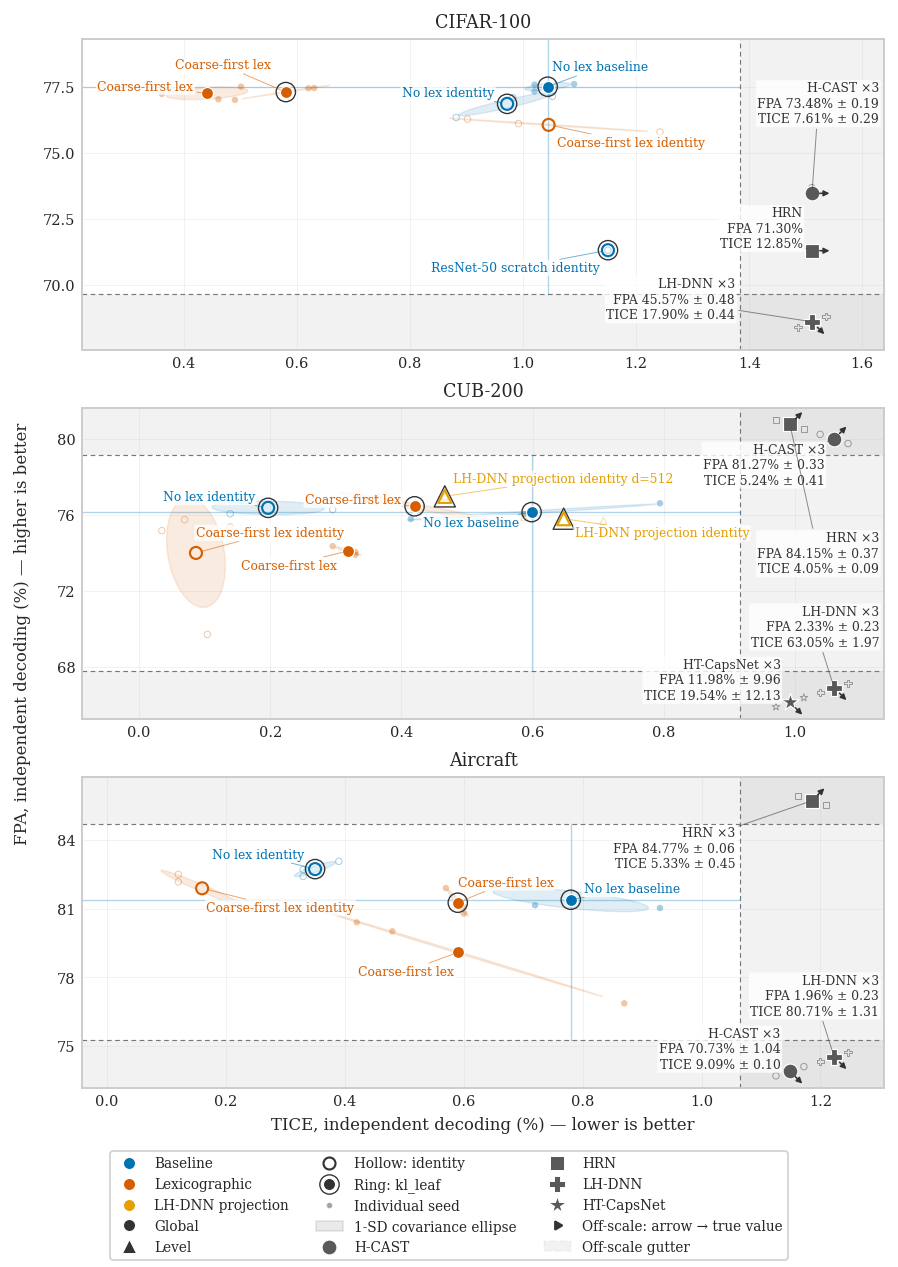

In [5]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    reference_rows=reference_rows, reference_specs=REFERENCE_SPECS,
    encoding=ENCODING,
    # The channels cannot separate every pair in this matrix (see the encoding
    # check above), so the direct labels stay on and carry the remainder.
    point_labels='all',
    baseline_selector=canonical_baseline,
    # The widest run matrix in the study: give the panels extra height so the
    # direct labels have somewhere to go.
    panel_height=2.65,
)

## Accuracy Per Hierarchy Level

Absolute coarse, middle, and fine accuracy for each run of this model family.
Runs are identified by their short code.

Cross-model references are deliberately left out, as in every current-run
notebook. They were trained with their own recipes and epoch budgets, so a bar
beside them invites a controlled reading the data does not support; the
trade-off figure above already places them, and the availability and summary
tables carry their exact numbers.

The Hier-COS matrix is wide, so the per-bar value labels are suppressed
automatically; read exact numbers from the summary table instead.

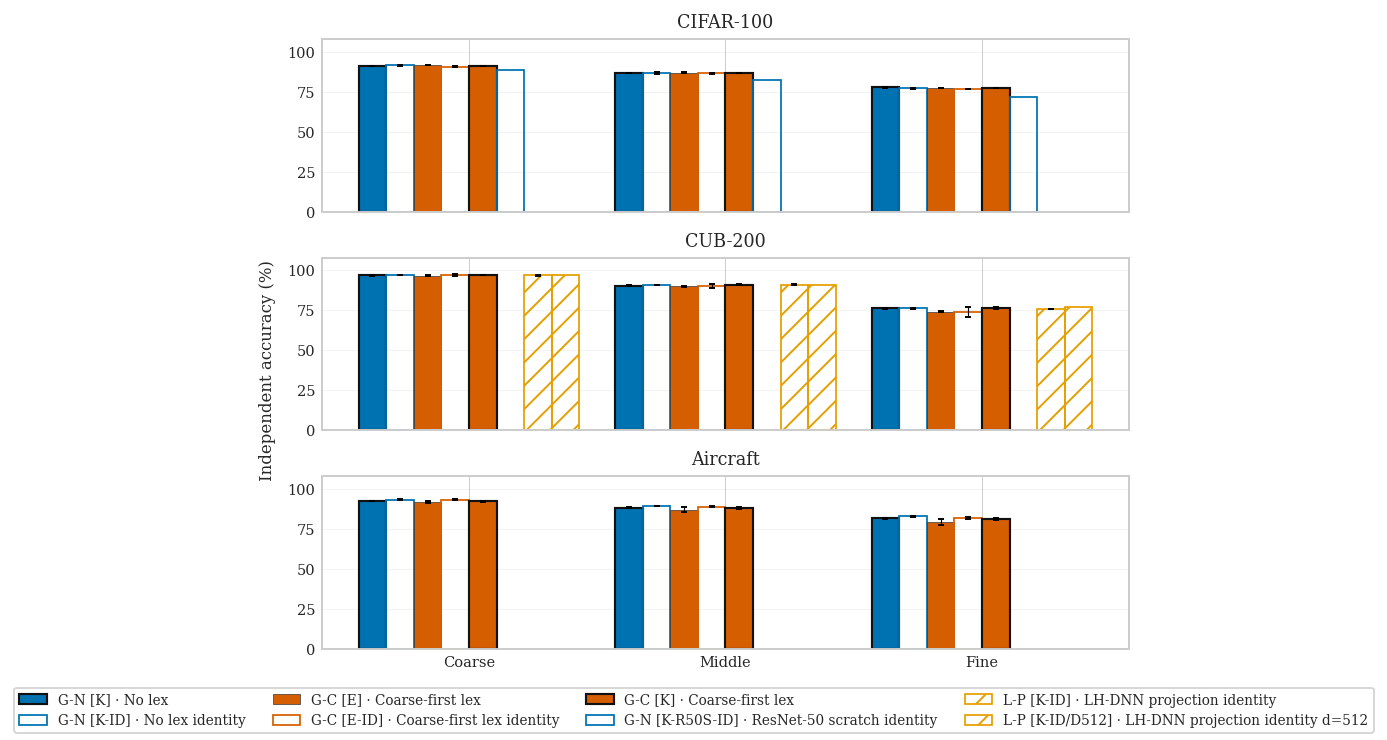

In [6]:
plot_level_accuracy(rows, DATASETS, FIGURE_DIR, SAVE_FIGURES, legend_ncol=4)

## Selected-Run Effects Across Hierarchy Levels

Each bar is the level-accuracy change of an available run from the canonical
no-lex baseline within the same dataset: global softmax, `kl_leaf`, orthonormal
frame, full transform. Deltas are computed per seed and then averaged, so only
seeds present in both runs contribute; the baseline itself and runs without a
matching baseline are omitted. Each panel has its own vertical scale, so compare
datasets through the printed values rather than the bar heights.

The CIFAR-100 ResNet-50 ablation bars are the exception flagged in the header:
their baseline here is WideResNet-28-8, so those bars mix the backbone change
with the pretraining change and are labelled accordingly.

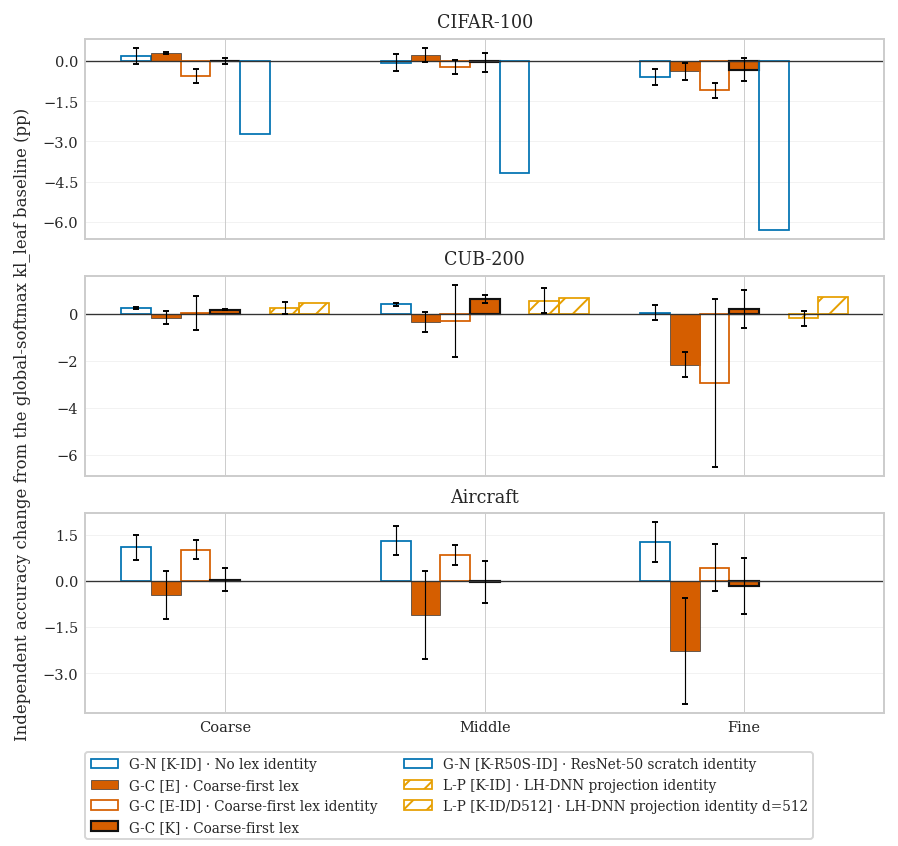

In [7]:
plot_level_accuracy_deltas(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    baseline_selector=canonical_baseline,
    baseline_name='the global-softmax kl_leaf baseline',
    # Bar labels spell out the whole configuration, so two columns per row.
    legend_ncol=2, panel_height=1.7,
)

## Run and Pareto Summary

A run is Pareto-optimal within a dataset when no other run of the same model
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. Reference models are not part of this comparison. AHD and
weighted AP are reported as additional columns but do not enter the Pareto test.

In [8]:
print_summary(rows, DATASETS, label_width=18)


CIFAR-100
  run                 n  epoch           FPA               TICE              AHD               weighted AP       status
  G-N [K]             3  93.7 ± 5.0      77.52% ± 0.16     1.04% ± 0.04      0.444 ± 0.003     80.07% ± 0.20     Pareto-optimal
  G-C [K]             3  93.7 ± 3.8      77.32% ± 0.26     0.58% ± 0.08      0.446 ± 0.005     79.81% ± 0.19     Pareto-optimal
  G-C [E]             3  97.0 ± 2.0      77.27% ± 0.24     0.44% ± 0.07      0.441 ± 0.002     79.81% ± 0.18     Pareto-optimal
  G-N [K-ID]          3  96.0 ± 4.4      76.87% ± 0.45     0.97% ± 0.09      0.449 ± 0.009     79.60% ± 0.45     dominated by G-C [E], G-C [K]
  G-C [E-ID]          3  94.3 ± 5.1      76.07% ± 0.25     1.05% ± 0.18      0.473 ± 0.009     79.14% ± 0.19     dominated by G-N [K], G-N [K-ID], G-C [E], G-C [K]
  G-N [K-R50S-ID]     1  87              71.32%            1.15%             0.576             74.36%            dominated by G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-C [K]

C